##  1.	Implement a basic Perceptron using Python and classify binary data.

Perceptron classification accuracy 1.0


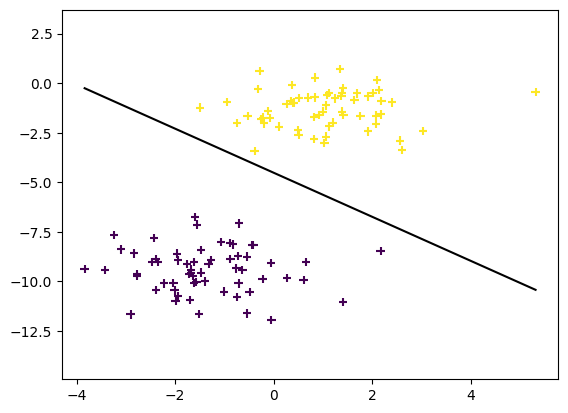

In [10]:
import numpy as np
def unit_step_func(x):
    return np.where(x > 0 , 1, 0)
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = unit_step_func
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_ = np.where(y > 0 , 1, 0)
        # learn weights
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)
                # Perceptron update rule
                update = self.lr * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias

        y_predicted = self.activation_func(linear_output)
        return y_predicted


# Testing
if __name__ == "__main__":
    # Imports
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn import datasets
    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    X, y = datasets.make_blobs(
        n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=123
    )
    p = Perceptron(learning_rate=0.01, n_iters=1000)
    p.fit(X_train, y_train)
    predictions = p.predict(X_test)
    print("Perceptron classification accuracy", accuracy(y_test, predictions))
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X_train[:, 0], X_train[:, 1], marker="+", c=y_train)
    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])
    x1_1 = (-p.weights[0] * x0_1 - p.bias) / p.weights[1]
    x1_2 = (-p.weights[0] * x0_2 - p.bias) / p.weights[1]
    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")
    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin - 3, ymax + 3])
    plt.show()


## 2    Build and train a Multilayer Perceptron (MLP) using TensorFlow/Keras on the MNIST dataset.

Epoch 1/15
422/422 - 7s - 18ms/step - accuracy: 0.8428 - loss: 0.5482 - val_accuracy: 0.9562 - val_loss: 0.1599
Epoch 2/15
422/422 - 3s - 8ms/step - accuracy: 0.9219 - loss: 0.2659 - val_accuracy: 0.9672 - val_loss: 0.1139
Epoch 3/15
422/422 - 3s - 7ms/step - accuracy: 0.9372 - loss: 0.2110 - val_accuracy: 0.9742 - val_loss: 0.0902
Epoch 4/15
422/422 - 3s - 7ms/step - accuracy: 0.9461 - loss: 0.1784 - val_accuracy: 0.9757 - val_loss: 0.0816
Epoch 5/15
422/422 - 4s - 10ms/step - accuracy: 0.9523 - loss: 0.1589 - val_accuracy: 0.9752 - val_loss: 0.0808
Epoch 6/15
422/422 - 3s - 7ms/step - accuracy: 0.9574 - loss: 0.1403 - val_accuracy: 0.9773 - val_loss: 0.0739
Epoch 7/15
422/422 - 3s - 7ms/step - accuracy: 0.9601 - loss: 0.1320 - val_accuracy: 0.9808 - val_loss: 0.0667
Epoch 8/15
422/422 - 3s - 7ms/step - accuracy: 0.9619 - loss: 0.1215 - val_accuracy: 0.9817 - val_loss: 0.0667
Epoch 9/15
422/422 - 5s - 12ms/step - accuracy: 0.9652 - loss: 0.1129 - val_accuracy: 0.9812 - val_loss: 0.067

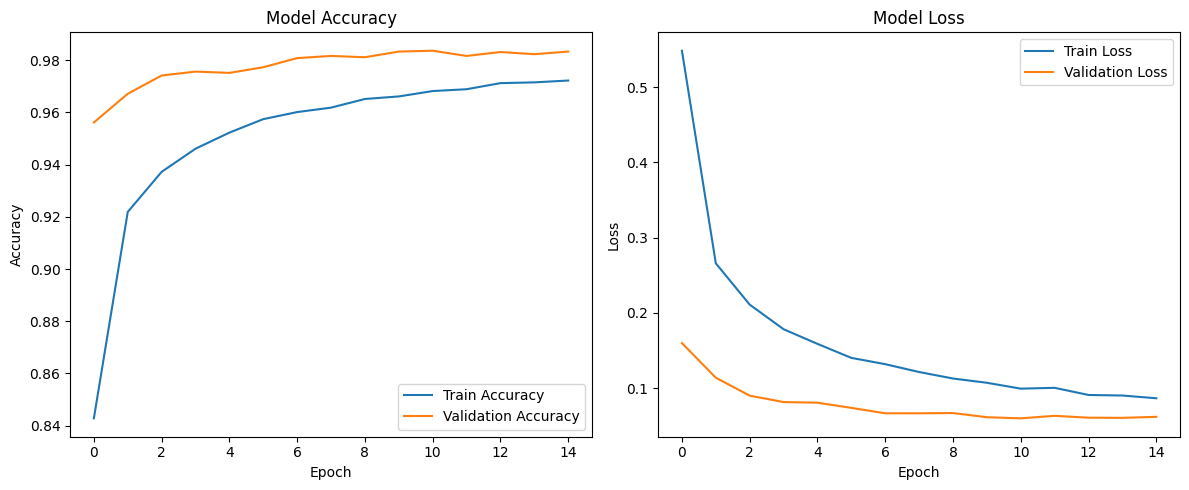


Model saved as 'mlp_mnist_model.h5'


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
# 2. Load and Preprocess the MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Reshape the data (28x28 images → 784 features)
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build the MLP Model with Dropout and Batch Normalization
model = models.Sequential([
    layers.Dense(128, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# 5. Train the Model and Store Training History
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)
# 6. Evaluate the Model on Test Data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# 7. Plot Training Curves (Accuracy and Loss)
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 8. Save the Trained Model
model.save("mlp_mnist_model.h5")
print("\nModel saved as 'mlp_mnist_model.h5'")


##  3.	Experiment with different activation functions (ReLU, sigmoid, tanh) and observe effects on learning.

In [14]:
#Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
# 2. Load the MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# 3. Normalize Pixel Values (0–255 → 0–1)
x_train, x_test = x_train / 255.0, x_test / 255.0
# 4. Convert Labels to One-Hot Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
# 5. Function to Create and Train a Simple Model with Different Activations
def test_activation(activation):
    print(f"\nTraining with activation = {activation}")
    # Build Model
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    # Compile Model
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    # Train Model (2 epochs for quick comparison)
    model.fit(x_train, y_train, epochs=2, batch_size=128, verbose=1)
    # Evaluate Model
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy with {activation}: {acc:.4f}")
# 6. Try Different Activation Functions
for act in ['relu', 'sigmoid', 'tanh']:
    test_activation(act)



Training with activation = relu
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8031 - loss: 0.7131
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9360 - loss: 0.2185
Test Accuracy with relu: 0.9528

Training with activation = sigmoid
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7129 - loss: 1.1956
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9108 - loss: 0.3385
Test Accuracy with sigmoid: 0.9261

Training with activation = tanh
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8002 - loss: 0.7077
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9328 - loss: 0.2387
Test Accuracy with tanh: 0.9432


## 4.	Compare optimizers (SGD, Adam, RMS prop) on convergence and performance.
     



Training using optimizer: sgd


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5458 - loss: 1.6613 - val_accuracy: 0.8775 - val_loss: 0.6343
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8544 - loss: 0.6351 - val_accuracy: 0.9015 - val_loss: 0.4250
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8782 - loss: 0.4788 - val_accuracy: 0.9110 - val_loss: 0.3562
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8893 - loss: 0.4162 - val_accuracy: 0.9170 - val_loss: 0.3198
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8983 - loss: 0.3787 - val_accuracy: 0.9227 - val_loss: 0.2985
Test Accuracy with sgd: 0.9074

Training using optimizer: rmsprop
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8413 - loss: 0.5852 - val_accuracy: 0.9525 - val_loss: 0.1683
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9446 - loss: 0.1896 - val_accuracy: 0.9683 - val_loss: 0.1221
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms

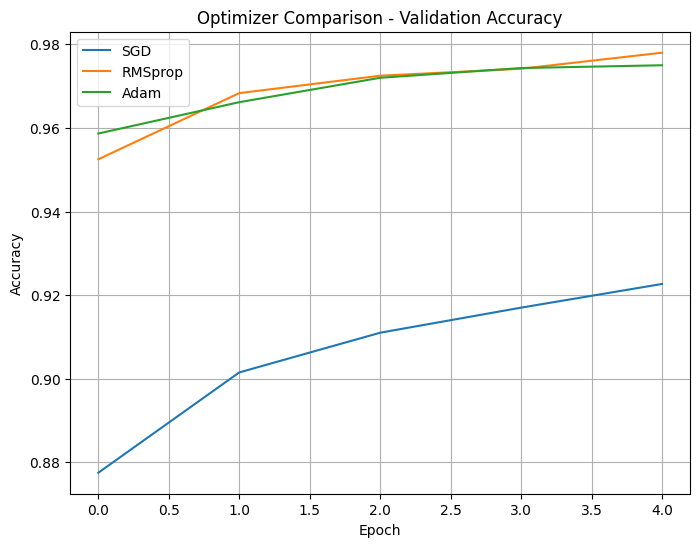

In [21]:
# Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 2. Function to Build and Train Model with Different Optimizers
def train_with_optimizer(optimizer_name):
    print(f"\nTraining using optimizer: {optimizer_name}")

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer_name,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy with {optimizer_name}: {test_acc:.4f}")

    return history

# 3. Train Models with Different Optimizers
history_sgd = train_with_optimizer('sgd')
history_rmsprop = train_with_optimizer('rmsprop')
history_adam = train_with_optimizer('adam')

# 4. Plot Accuracy Comparison
plt.figure(figsize=(8, 6))
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop')
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.title('Optimizer Comparison - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show() 


## 5.	 Implement Convolutional Neural Networks (CNN) for image classification on the CIFAR-10 dataset.

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.3527 - loss: 1.7482 - val_accuracy: 0.5435 - val_loss: 1.2600
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.5584 - loss: 1.2260 - val_accuracy: 0.6097 - val_loss: 1.0948
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6259 - loss: 1.0576 - val_accuracy: 0.6474 - val_loss: 0.9880
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 61ms/step - accuracy: 0.6742 - loss: 0.9318 - val_accuracy: 0.6709 - val_loss: 0.9444
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7004 - loss: 0.8497 - val_accuracy: 0.6895 - val_loss: 0.8817
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.7289 - loss: 0.7750 - val_accuracy: 0.7046 - val_loss: 0.8725
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 48ms/step - accuracy: 0.7436 - loss: 0.7331 - val_accuracy: 0.6986 - val_loss: 0.8841
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.7621 -

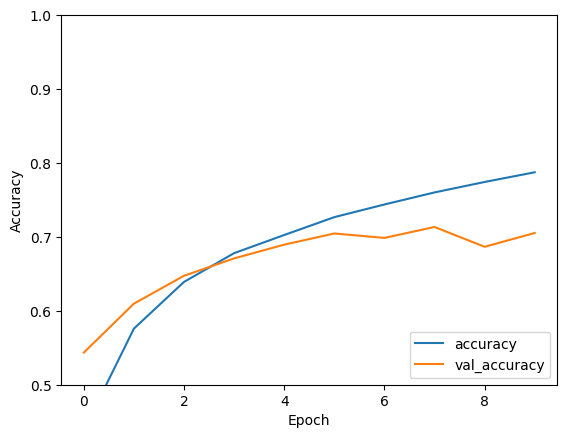

313/313 - 5s - 15ms/step - accuracy: 0.7053 - loss: 0.8910
Test Accuracy: 0.705299973487854
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
cat


In [16]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
# 1. Load and preprocess the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
# 2. Build the CNN model
model = models.Sequential()
# Convolutional Base
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Dense Layers (Classifier)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # Output layer with 10 units for 10 classes
# 3. Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
# 4. Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))
# 5. Evaluate the model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"Test Accuracy: {test_acc}")
# Make predictions on a sample image
predictions = model.predict(test_images)
print(class_names[tf.argmax(predictions[0])])


## 6.	Perform data augmentation techniques and evaluate improvements in model accuracy.



In [24]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(datagen.flow(x_train, y_train, batch_size=64),
          epochs=5,
          validation_data=(x_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 149ms/step - accuracy: 0.3349 - loss: 1.8116 - val_accuracy: 0.5206 - val_loss: 1.3665
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 121s 154ms/step - accuracy: 0.5170 - loss: 1.3482 - val_accuracy: 0.6116 - val_loss: 1.1233
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 127ms/step - accuracy: 0.5781 - loss: 1.1999 - val_accuracy: 0.6330 - val_loss: 1.0404
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.6032 - loss: 1.1287 - val_accuracy: 0.6526 - val_loss: 0.9972
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.6276 - loss: 1.0691 - val_accuracy: 0.6664 - val_loss: 0.9598


## 7.	Evaluate model using metrics such as precision, recall, F1-score, and ROC curves.

Precision: 0.75
Recall: 0.75
F1-Score: 0.75


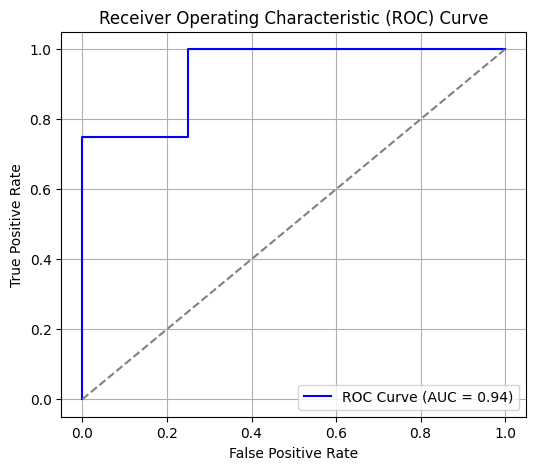

In [20]:
#Import Required Libraries
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
# 2. Define True Labels and Predicted Outputs
y_true = [1, 0, 1, 1, 0, 0, 1, 0]     # Actual class labels
y_pred = [1, 0, 1, 0, 0, 1, 1, 0]     # Predicted class labels
y_prob = [0.9, 0.2, 0.8, 0.4, 0.3, 0.7, 0.85, 0.1]   # Predicted probabilities (for ROC)
# 3. Calculate Evaluation Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
# 4. Display the Metrics
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1-Score:", round(f1, 2))
# 5. Generate ROC Curve Values
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
# 6. Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label="ROC Curve (AUC = %.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## 8.	Implement Recurrent Neural Networks (RNN) and LSTMs for sentiment analysis on the IMDB dataset.

In [19]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
import numpy as np

V, L = 10000, 200
(xtr, ytr), (xte, yte) = imdb.load_data(num_words=V)
xtr = pad_sequences(xtr, maxlen=L)
xte = pad_sequences(xte, maxlen=L)

def build(cell):
    return Sequential([
        Embedding(V, 32, input_length=L),
        cell(32),
        Dense(1, activation='sigmoid')
    ])

nets = {'SimpleRNN': SimpleRNN, 'LSTM': LSTM}
trained = {}

for n, c in nets.items():
    m = build(c)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(xtr, ytr, epochs=3, batch_size=128, validation_split=0.2, verbose=2)
    print(f"\n{n} Test Accuracy: {m.evaluate(xte, yte, verbose=0)[1]:.4f}")
    trained[n] = m

i = np.random.randint(len(xte))
s, lbl = xte[i:i+1], yte[i]
rnn_p  = trained['SimpleRNN'].predict(s, verbose=0)[0][0]
lstm_p = trained['LSTM'].predict(s, verbose=0)[0][0]

wi = imdb.get_word_index()
rev = {v+3:k for k,v in wi.items()} | {0:'<PAD>',1:'<START>',2:'<UNK>',3:'<UNUSED>'}
text = " ".join(rev.get(j,'?') for j in xte[i])

print("\n==\nSample Review:\n")
print(text)
print("\nTrue Label:", "Positive" if lbl else "Negative")
print(f"RNN Prediction:  {rnn_p:.3f} → {'Positive' if rnn_p>0.5 else 'Negative'}")
print(f"LSTM Prediction: {lstm_p:.3f} → {'Positive' if lstm_p>0.5 else 'Negative'}")
print("==")


Epoch 1/3
157/157 - 14s - 91ms/step - accuracy: 0.6335 - loss: 0.6238 - val_accuracy: 0.8022 - val_loss: 0.4479
Epoch 2/3
157/157 - 11s - 69ms/step - accuracy: 0.8415 - loss: 0.3705 - val_accuracy: 0.7930 - val_loss: 0.4414
Epoch 3/3
157/157 - 11s - 70ms/step - accuracy: 0.8934 - loss: 0.2755 - val_accuracy: 0.8176 - val_loss: 0.4108

SimpleRNN Test Accuracy: 0.8218
Epoch 1/3
157/157 - 25s - 156ms/step - accuracy: 0.7546 - loss: 0.4989 - val_accuracy: 0.8672 - val_loss: 0.3302
Epoch 2/3
157/157 - 41s - 263ms/step - accuracy: 0.8978 - loss: 0.2646 - val_accuracy: 0.8538 - val_loss: 0.3426
Epoch 3/3
157/157 - 23s - 147ms/step - accuracy: 0.9301 - loss: 0.1936 - val_accuracy: 0.8716 - val_loss: 0.3388

LSTM Test Accuracy: 0.8602



==
Sample Review:

car in the beginning of the movie goes to bar is approached by a biker gang who ruins his chances with a very lovely lady offer him a job he goes back to their place refuses the police ask him to accept their ya go what plays out is a very annoying little film that sees the hero not really do all that much and a biker gang that can kill and for some reason the police can not pin a crime on them i am not sure why the female biker did what she did at the end but hey it is a bad movie you always get scenes that make little sense i am still trying to figure out if i <UNK> it when they said the hero of the piece was a stunt car driver they may have said stock car driver because why would a stunt <UNK> be racing and i wouldn't think it would be all that <UNK> for a stunt car to crash the actors are bad and all the <UNK> are pretty annoying and the hero is kind of incompetent really this movie is not full of kicks but it is the <UNK>

True Label: Negative
RNN Prediction:  